# 5.2 — Loss & Cross-Entropy, at the computer

Do the **pen-and-paper worksheet first**. Here you check your answers, *see* why cross-entropy's
shape is perfect for the job, and preview softmax.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

# --- our tiny network, built in notebook 01 ---
def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-z))

def forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    h  = relu(z1)
    z2 = W2 @ h + b2
    return z1, h, z2, sigmoid(z2)

x  = np.array([1.0, 2.0])
W1 = np.array([[0.5, -1.0], [1.0, 0.5]]); b1 = np.array([0.5, -1.0])
W2 = np.array([-1.0, 2.0]);               b2 = -2.0

## 1. The shape of the penalty (Module 1.2 eyes on)

For a true label $y=1$, cross-entropy charges $-\ln(\hat{y})$ and MSE charges $(\hat{y}-1)^2$.
Plot both bills across every possible prediction and compare their tempers.

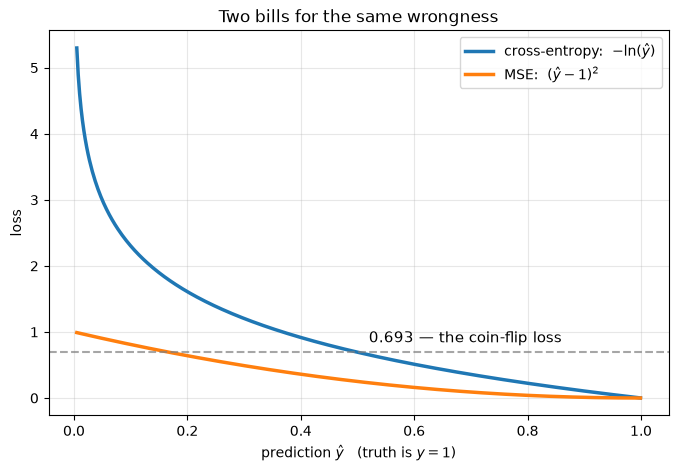

In [2]:
p = np.linspace(0.005, 0.999, 400)     # predictions from almost-0 to almost-1

plt.figure(figsize=(8, 5))
plt.plot(p, -np.log(p), linewidth=2.5, label="cross-entropy:  $-\\ln(\\hat{y})$")
plt.plot(p, (p - 1)**2, linewidth=2.5, label="MSE:  $(\\hat{y}-1)^2$")
plt.axhline(np.log(2), color="grey", linestyle="--", alpha=0.7)
plt.annotate("0.693 — the coin-flip loss", (0.52, np.log(2) + 0.15), fontsize=11)
plt.xlabel("prediction $\\hat{y}$   (truth is $y=1$)"); plt.ylabel("loss")
plt.title("Two bills for the same wrongness")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
# Look left: as y_hat -> 0 (confidently WRONG), MSE politely tops out near 1.
# Cross-entropy heads for infinity. That wall is the behaviour we want.

## 2. Score the network from notebook 01

The forward pass said $\hat{y} = 0.5$; the truth is $y = 1$. Send it the bill.

In [3]:
def cross_entropy(y_hat, y):
    # one term is always zero because y is 0 or 1 — exactly the branch-picking you did on paper
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

_, _, _, y_hat = forward(x, W1, b1, W2, b2)
print(f"prediction: {y_hat:.3f},  loss: {cross_entropy(y_hat, 1):.4f}")   # hello, 0.693

# The whole wrongness scale, as a table (f-strings: the :.3f part controls decimal places)
for guess in [0.99, 0.9, 0.73, 0.5, 0.27, 0.1, 0.01]:
    print(f"  y_hat = {guess:.2f}  ->  loss = {cross_entropy(guess, 1):7.3f}")

prediction: 0.500,  loss: 0.6931
  y_hat = 0.99  ->  loss =   0.010
  y_hat = 0.90  ->  loss =   0.105
  y_hat = 0.73  ->  loss =   0.315
  y_hat = 0.50  ->  loss =   0.693
  y_hat = 0.27  ->  loss =   1.309
  y_hat = 0.10  ->  loss =   2.303
  y_hat = 0.01  ->  loss =   4.605


## 3. Softmax preview — scores into probabilities

Module 0.5's $e^x$ + Module 0.6's $\Sigma$, four lines. This is the output end of every classifier
(and of GPT — its "scores" are one per word in the vocabulary).

scores (2, 0)  -> [0.881 0.119]
scores (3, 1)  -> [0.881 0.119]


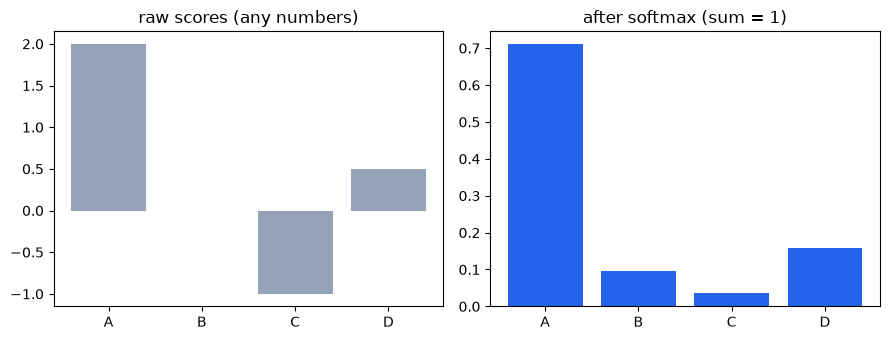

sum of probabilities: 1.0


In [4]:
def softmax(scores):
    exps = np.exp(scores)          # every score becomes positive (Module 0.5)
    return exps / np.sum(exps)     # divide by the total so they sum to 1 (Module 0.6)

print("scores (2, 0)  ->", softmax(np.array([2.0, 0.0])).round(3))
print("scores (3, 1)  ->", softmax(np.array([3.0, 1.0])).round(3))   # worksheet D13: identical!

scores = np.array([2.0, 0.0, -1.0, 0.5])
probs = softmax(scores)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(range(4), scores, color="#94a3b8"); axes[0].set_title("raw scores (any numbers)")
axes[1].bar(range(4), probs,  color="#2563eb"); axes[1].set_title("after softmax (sum = 1)")
for ax in axes: ax.set_xticks(range(4), ["A", "B", "C", "D"])
plt.tight_layout(); plt.show()
print("sum of probabilities:", probs.sum())

In [5]:
# YOUR TURN
# 1) Check worksheet Part B: cross_entropy(0.73, 0), cross_entropy(0.73, 1),
#    and the mean loss from problem 7 (np.mean of a list).

# 2) Walk into the ln(0) trap on purpose: cross_entropy(1.0, 0). What comes back?
#    Then try cross_entropy(0.9999999, 0) — this "clipping" is what real libraries do.

# 3) Softmax the scores (5, 5, 5). Predict the answer before running.

## 4. Why this number matters

The loss is the ONE number the whole training process will try to shrink. Notebook 03 asks the
key question — *which way should each weight move to shrink it?* — and Module 3's chain rule
answers in full.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 5.3 — backprop, the summit.*